### 🛠️ Install Dependencies (Run once, then Kernel → Restart)

In [ ]:
%pip install opencv-python numpy ultralytics matplotlib pandas

# 🅿️ Parking Slot Detection — Image Pipeline

**Key fix**: Each slot is cropped individually and fed to the model directly —  
this matches how the model was trained (on slot-level crops, not full frames).

**Model**: `runs/parking_detect/yolov8n_parking_status/weights/best.pt`  
**Classes**: `0 = car` (occupied) · `1 = free` (empty)  
**Slot ROIs**: Auto-loaded from `parking.yolov8/train/labels/*.txt` (YOLO OBB polygon)

## Cell 1 — Imports

In [23]:
import cv2
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from ultralytics import YOLO

print('✅ Imports OK')

✅ Imports OK


## Cell 2 — Configuration

In [24]:
# ── Detection model ──────────────────────────────────────────────────────
MODEL_PATH  = 'runs/parking_detect/yolov8n_parking_status/weights/best.pt'
CLASS_CAR   = 0    # 'car'  -> occupied
CLASS_FREE  = 1    # 'free' -> empty

# Lower confidence so partial/toy car detections are not missed
CONF_THRESH = 0.25

# ── Annotation source ─────────────────────────────────────────────────────
ANNOT_DIR   = 'parking.yolov8/train'
ANNOT_IMAGE = glob.glob(os.path.join(ANNOT_DIR, 'images', '*'))[0]
ANNOT_LABEL = glob.glob(os.path.join(ANNOT_DIR, 'labels', '*.txt'))[0]

# ── Test images ───────────────────────────────────────────────────────────
IMAGE_DIR   = 'parking'
image_paths = sorted(
    glob.glob(os.path.join(IMAGE_DIR, '*.jpeg')) +
    glob.glob(os.path.join(IMAGE_DIR, '*.jpg'))
)

# ── Pixel-difference fallback threshold (0-255, lower = more sensitive) ──
# A slot is flagged occupied if mean absolute pixel diff from empty > this value.
PIXEL_DIFF_THRESH = 30

print(f'Annotation image : {os.path.basename(ANNOT_IMAGE)}')
print(f'Annotation label : {os.path.basename(ANNOT_LABEL)}')
print(f'Test images found: {len(image_paths)}')

Annotation image : WhatsApp Image 2026-03-30 at 8-23-39 PM (1)_jpeg.rf.sP5wObBgVnSamJwMWiHq.jpeg
Annotation label : WhatsApp Image 2026-03-30 at 8-23-39 PM (1)_jpeg.rf.sP5wObBgVnSamJwMWiHq.txt
Test images found: 9


## Cell 3 — Load Slot ROIs from YOLO OBB Annotation

In [25]:
def load_slots_from_yolo_obb(label_path, img_path):
    """
    Parse YOLO OBB label: class x1 y1 x2 y2 x3 y3 x4 y4 (normalised)
    Returns list of pixel (x1, y1, x2, y2) axis-aligned boxes.
    """
    ref_img = cv2.imread(img_path)
    img_h, img_w = ref_img.shape[:2]
    print(f'Reference image: {img_w} x {img_h}')

    boxes = []
    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 9:
                continue
            coords = list(map(float, parts[1:9]))
            xs = [coords[i]   * img_w for i in range(0, 8, 2)]
            ys = [coords[i+1] * img_h for i in range(0, 8, 2)]
            boxes.append((int(min(xs)), int(min(ys)),
                          int(max(xs)), int(max(ys))))
    return boxes, ref_img


raw_boxes, ref_image = load_slots_from_yolo_obb(ANNOT_LABEL, ANNOT_IMAGE)
print(f'Slots found: {len(raw_boxes)}')

n     = len(raw_boxes)
split = n // 2
SLOTS = {'A': {}, 'B': {}}
for i, box in enumerate(raw_boxes[:split]):
    SLOTS['A'][f'A{i+1}'] = box
for i, box in enumerate(raw_boxes[split:]):
    SLOTS['B'][f'B{i+1}'] = box

print('\nSlot assignments:')
for g, slots in SLOTS.items():
    for label, box in slots.items():
        print(f'  {label}: {box}')

Reference image: 1280 x 960
Slots found: 6

Slot assignments:
  A1: (125, 85, 539, 262)
  A2: (91, 258, 536, 456)
  A3: (54, 454, 531, 679)
  B1: (698, 94, 1137, 254)
  B2: (704, 262, 1166, 430)
  B3: (712, 437, 1200, 629)


## Cell 4 — Visualise Slots on Reference Image

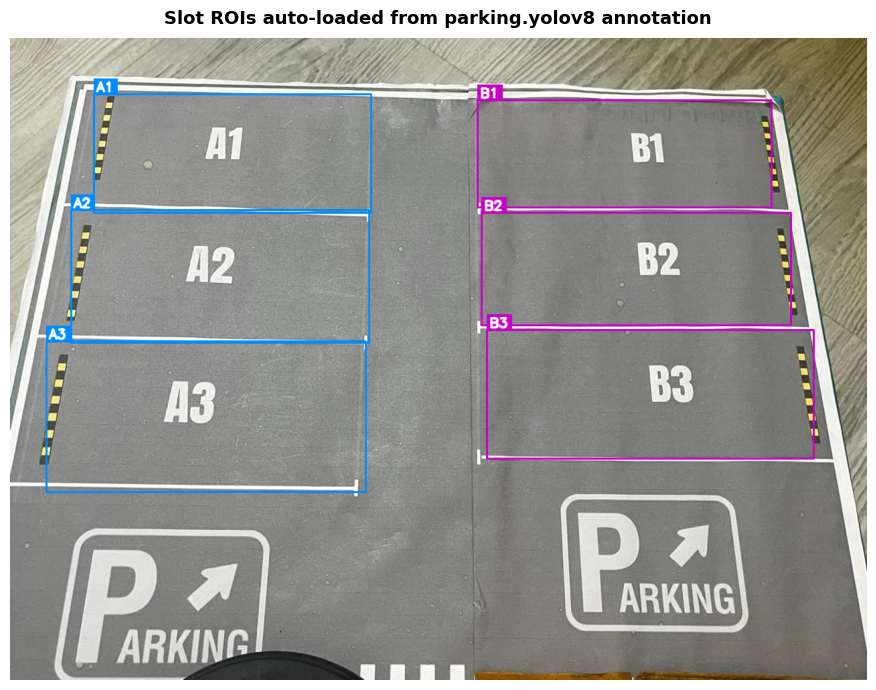

In [26]:
FONT = cv2.FONT_HERSHEY_SIMPLEX

def show_bgr(img_bgr, title=''):
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(14, 7))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.title(title, fontsize=13, fontweight='bold', pad=10)
    plt.tight_layout()
    plt.show()

vis = ref_image.copy()
for g, slots in SLOTS.items():
    color = (255, 140, 0) if g == 'A' else (200, 0, 200)
    for label, (x1, y1, x2, y2) in slots.items():
        cv2.rectangle(vis, (x1,y1), (x2,y2), color, 2)
        ts, _ = cv2.getTextSize(label, FONT, 0.65, 2)
        cv2.rectangle(vis, (x1, y1-ts[1]-8), (x1+ts[0]+8, y1), color, -1)
        cv2.putText(vis, label, (x1+4, y1-4), FONT, 0.65,
                    (255,255,255), 2, cv2.LINE_AA)

show_bgr(vis, 'Slot ROIs auto-loaded from parking.yolov8 annotation')

## Cell 5 — Build Empty Slot Reference Crops

Each slot crop from the **empty reference image** is saved.  
This is used as the pixel-difference fallback.

In [27]:
def crop_slot(img, box, scale_x=1.0, scale_y=1.0):
    """Crop a slot BOX from img, optionally scaling the coords first."""
    x1 = max(0, int(box[0] * scale_x))
    y1 = max(0, int(box[1] * scale_y))
    x2 = min(img.shape[1], int(box[2] * scale_x))
    y2 = min(img.shape[0], int(box[3] * scale_y))
    if x2 <= x1 or y2 <= y1:
        return None
    return img[y1:y2, x1:x2]


# Store reference (empty) crops for each slot
EMPTY_CROPS = {}
for g, slots in SLOTS.items():
    for label, box in slots.items():
        crop = crop_slot(ref_image, box)
        if crop is not None and crop.size > 0:
            EMPTY_CROPS[label] = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)

print(f'Empty reference crops saved: {list(EMPTY_CROPS.keys())}')

Empty reference crops saved: ['A1', 'A2', 'A3', 'B1', 'B2', 'B3']


## Cell 6 — Occupancy Detection (Crop + Model  +  Pixel Diff Fallback)

### Strategy (applied for EVERY slot, A and B):
1. **Crop** the slot ROI from the current frame (with slight padding)
2. **Run the parking model on the crop** — if class `car` is detected → **Occupied**
3. **Pixel-diff fallback** — compare crop to the empty reference crop.  
   If mean absolute difference > threshold → **Occupied**  
   Both must agree for Empty; either can mark Occupied.

In [28]:
CROP_PADDING = 0.05   # 5% padding around each slot crop

def is_slot_occupied(model, frame, slot_box, empty_gray_crop, label):
    """
    Two-strategy occupancy check:
      1. Run model on the slot crop.
      2. Pixel-diff comparison with the empty reference crop.
    Returns (occupied: bool, method: str)
    """
    h, w = frame.shape[:2]
    x1, y1, x2, y2 = slot_box

    # Add small padding so partially-in-slot vehicles are captured
    bw, bh = x2 - x1, y2 - y1
    pad_x = int(bw * CROP_PADDING)
    pad_y = int(bh * CROP_PADDING)
    cx1 = max(0, x1 - pad_x)
    cy1 = max(0, y1 - pad_y)
    cx2 = min(w,  x2 + pad_x)
    cy2 = min(h,  y2 + pad_y)

    slot_crop = frame[cy1:cy2, cx1:cx2]
    if slot_crop.size == 0:
        return False, 'empty_crop'

    # ── Strategy 1: run model on the crop ───────────────────────────────
    try:
        results = model(slot_crop, conf=CONF_THRESH, imgsz=320, verbose=False)
        for r in results:
            for box in r.boxes:
                if int(box.cls[0]) == CLASS_CAR:
                    return True, 'model'
    except Exception:
        pass

    # ── Strategy 2: pixel-difference vs empty reference ──────────────────
    if empty_gray_crop is not None:
        try:
            crop_gray = cv2.cvtColor(slot_crop, cv2.COLOR_BGR2GRAY)
            # Resize to match reference crop size
            ref_resized = cv2.resize(empty_gray_crop,
                                     (crop_gray.shape[1], crop_gray.shape[0]))
            diff = np.mean(np.abs(crop_gray.astype(np.float32) -
                                  ref_resized.astype(np.float32)))
            if diff > PIXEL_DIFF_THRESH:
                return True, f'pixel_diff({diff:.1f})'
        except Exception:
            pass

    return False, 'clear'

print('Occupancy function ready')

Occupancy function ready


## Cell 7 — Drawing Helpers

In [29]:
def draw_slot(img, slot_box, label, occupied, method=''):
    x1, y1, x2, y2 = slot_box
    color_bgr = (0, 0, 220) if occupied else (0, 200, 60)
    cv2.rectangle(img, (x1, y1), (x2, y2), color_bgr, 2)
    status = 'Occupied' if occupied else 'Empty'
    text   = f'{label} - {status}'
    ts, _  = cv2.getTextSize(text, FONT, 0.55, 1)
    cv2.rectangle(img, (x1, y1-ts[1]-8), (x1+ts[0]+8, y1), color_bgr, -1)
    cv2.putText(img, text, (x1+4, y1-4), FONT, 0.55,
                (255,255,255), 1, cv2.LINE_AA)

def draw_dashboard(img, a_occ, a_free, b_occ, b_free):
    h, w = img.shape[:2]
    dash_h = 56
    overlay = img.copy()
    cv2.rectangle(overlay, (0, h-dash_h), (w, h), (20,20,20), -1)
    cv2.addWeighted(overlay, 0.75, img, 0.25, 0, img)
    cv2.line(img, (0, h-dash_h), (w, h-dash_h), (80,80,80), 1)
    cv2.putText(img,
                f'A Slots  ->  Occupied: {a_occ}  |  Empty: {a_free}',
                (20, h-dash_h+22), FONT, 0.65, (120,220,80), 2, cv2.LINE_AA)
    cv2.putText(img,
                f'B Slots  ->  Occupied: {b_occ}  |  Empty: {b_free}',
                (20, h-dash_h+46), FONT, 0.65, (255,180,80), 2, cv2.LINE_AA)

print('Drawing helpers ready')

Drawing helpers ready


## Cell 8 — Load Detection Model

In [30]:
print('Loading model ...')
model = YOLO(MODEL_PATH)
print('✅ Model loaded:', MODEL_PATH)

Loading model ...
✅ Model loaded: runs/parking_detect/yolov8n_parking_status/weights/best.pt


## Cell 9 — Core Processing Function

In [31]:
def process_image(img_path, show=True):
    frame = cv2.imread(img_path)
    if frame is None:
        print(f'Cannot read: {img_path}')
        return None, {}

    h, w = frame.shape[:2]
    ref_h, ref_w = ref_image.shape[:2]
    sx, sy = w / ref_w, h / ref_h

    def scale(box):
        return (int(box[0]*sx), int(box[1]*sy),
                int(box[2]*sx), int(box[3]*sy))

    status  = {}
    methods = {}
    a_occ = a_free = b_occ = b_free = 0

    for group in ('A', 'B'):
        for label, raw_box in SLOTS[group].items():
            slot_box  = scale(raw_box)
            empty_ref = EMPTY_CROPS.get(label)

            occ, method = is_slot_occupied(
                model, frame, slot_box, empty_ref, label
            )
            status[label]  = 'Occupied' if occ else 'Empty'
            methods[label] = method
            draw_slot(frame, slot_box, label, occ, method)

            if group == 'A':
                if occ: a_occ  += 1
                else:   a_free += 1
            else:
                if occ: b_occ  += 1
                else:   b_free += 1

    draw_dashboard(frame, a_occ, a_free, b_occ, b_free)

    if show:
        title = (f'{os.path.basename(img_path)}  |  '
                 f'A -> Occ:{a_occ} Free:{a_free}   '
                 f'B -> Occ:{b_occ} Free:{b_free}')
        show_bgr(frame, title)

        print(f"{'Slot':<6} {'Status':<12} {'Method'}")
        print('-' * 35)
        for k, v in status.items():
            icon = '[OCC]' if v == 'Occupied' else '[FREE]'
            print(f"{k:<6} {icon} {v:<10}  via {methods[k]}")
        print()

    return frame, status

print('process_image() ready')

process_image() ready


## Cell 10 — Run on All Images in `parking/`


  Image: 1.jpeg


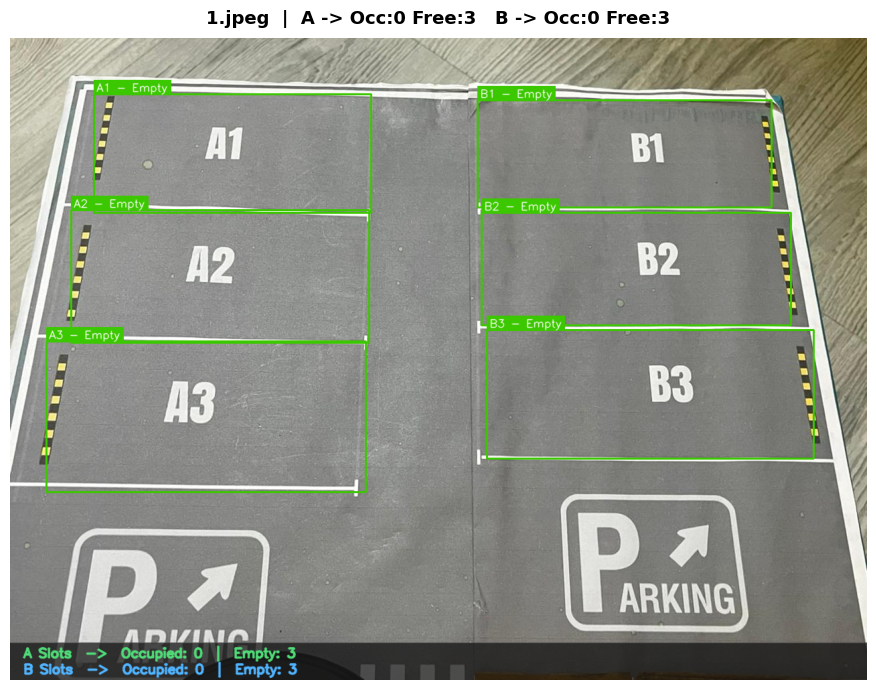

Slot   Status       Method
-----------------------------------
A1     [FREE] Empty       via clear
A2     [FREE] Empty       via clear
A3     [FREE] Empty       via clear
B1     [FREE] Empty       via clear
B2     [FREE] Empty       via clear
B3     [FREE] Empty       via clear


  Image: 2.jpeg


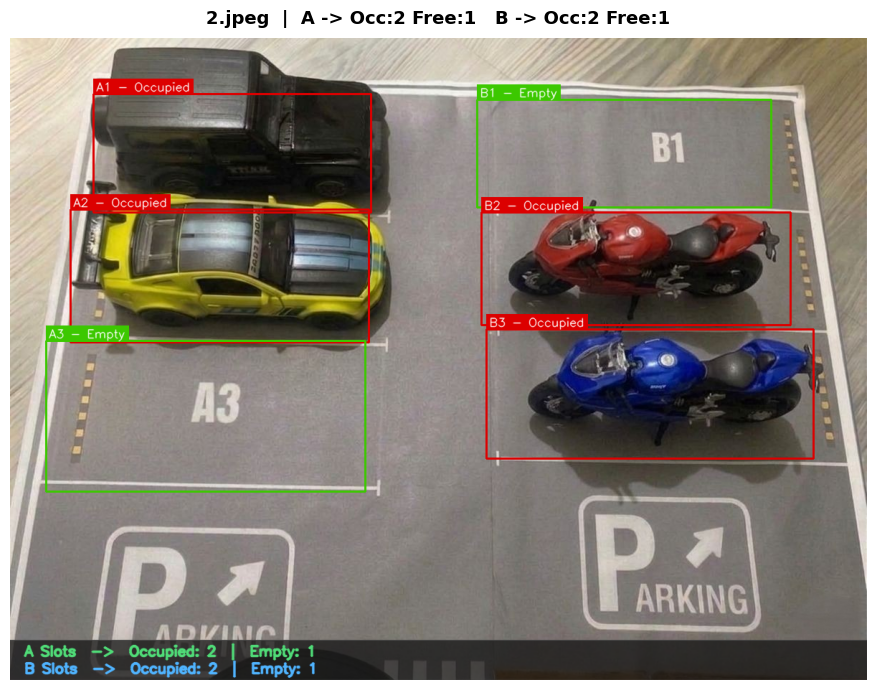

Slot   Status       Method
-----------------------------------
A1     [OCC] Occupied    via pixel_diff(92.2)
A2     [OCC] Occupied    via pixel_diff(66.4)
A3     [FREE] Empty       via clear
B1     [FREE] Empty       via clear
B2     [OCC] Occupied    via model
B3     [OCC] Occupied    via model


  Image: 3.jpeg


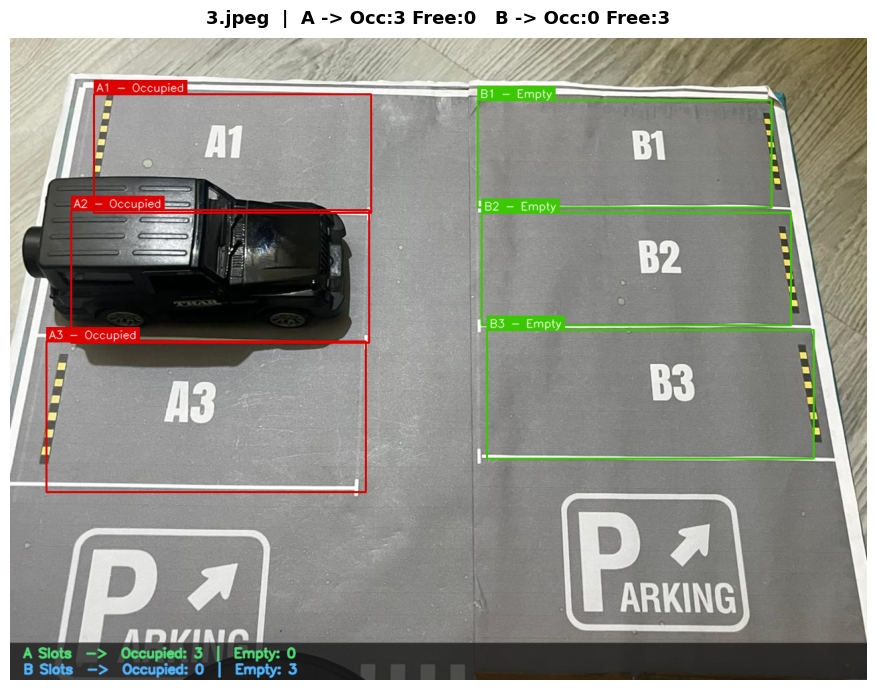

Slot   Status       Method
-----------------------------------
A1     [OCC] Occupied    via pixel_diff(33.1)
A2     [OCC] Occupied    via pixel_diff(98.2)
A3     [OCC] Occupied    via pixel_diff(31.1)
B1     [FREE] Empty       via clear
B2     [FREE] Empty       via clear
B3     [FREE] Empty       via clear


  Image: 4.jpeg


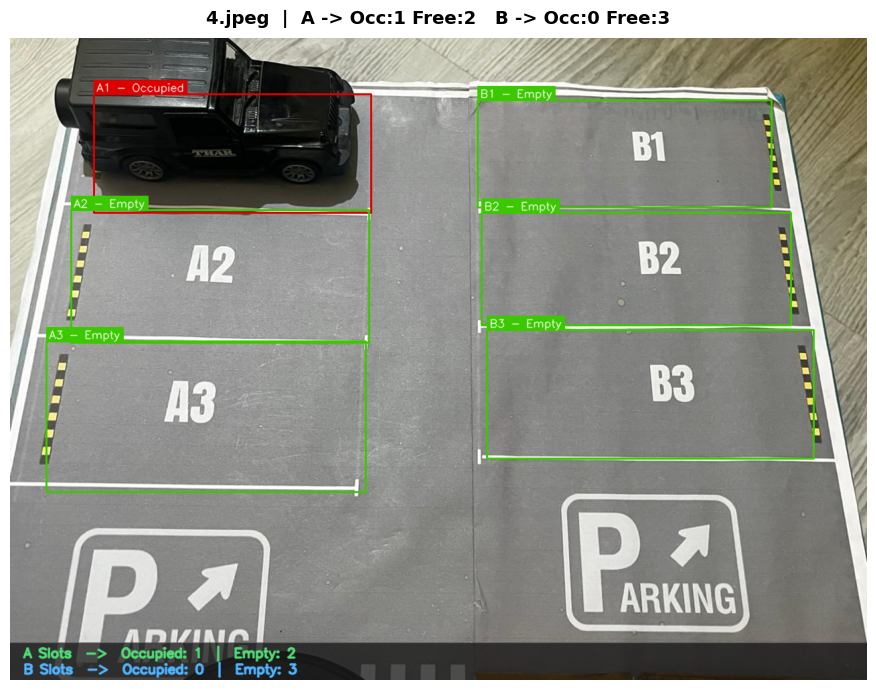

Slot   Status       Method
-----------------------------------
A1     [OCC] Occupied    via pixel_diff(99.9)
A2     [FREE] Empty       via clear
A3     [FREE] Empty       via clear
B1     [FREE] Empty       via clear
B2     [FREE] Empty       via clear
B3     [FREE] Empty       via clear


  Image: 5.jpeg


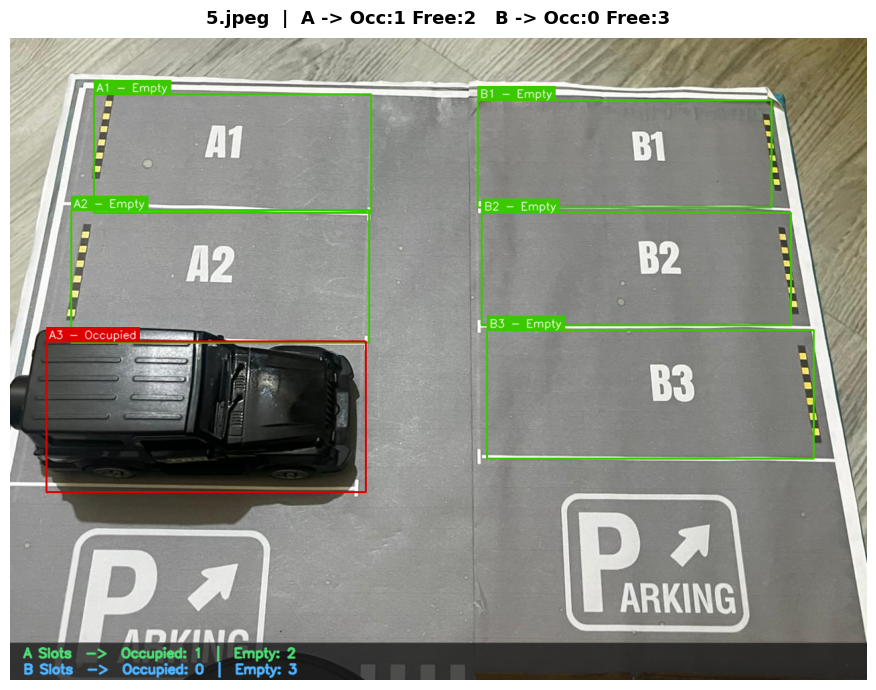

Slot   Status       Method
-----------------------------------
A1     [FREE] Empty       via clear
A2     [FREE] Empty       via clear
A3     [OCC] Occupied    via pixel_diff(86.4)
B1     [FREE] Empty       via clear
B2     [FREE] Empty       via clear
B3     [FREE] Empty       via clear


  Image: 6.jpeg


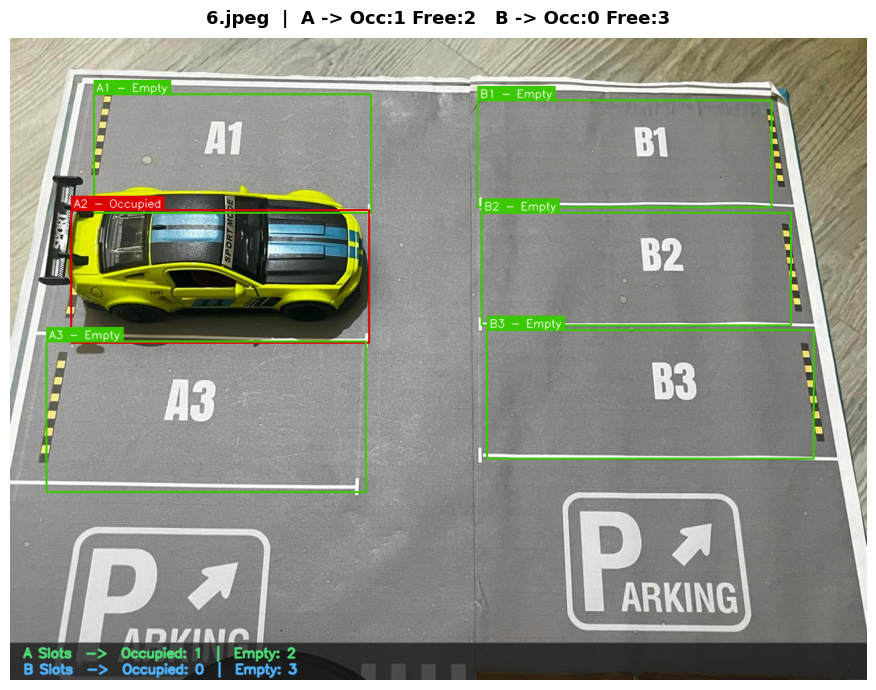

Slot   Status       Method
-----------------------------------
A1     [FREE] Empty       via clear
A2     [OCC] Occupied    via pixel_diff(74.6)
A3     [FREE] Empty       via clear
B1     [FREE] Empty       via clear
B2     [FREE] Empty       via clear
B3     [FREE] Empty       via clear


  Image: 7.jpeg


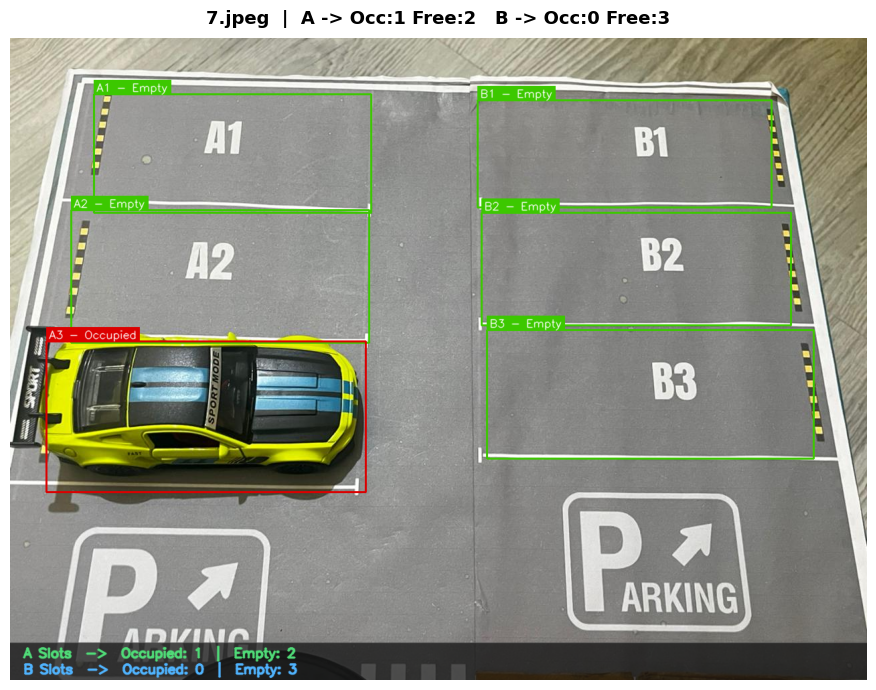

Slot   Status       Method
-----------------------------------
A1     [FREE] Empty       via clear
A2     [FREE] Empty       via clear
A3     [OCC] Occupied    via pixel_diff(69.4)
B1     [FREE] Empty       via clear
B2     [FREE] Empty       via clear
B3     [FREE] Empty       via clear


  Image: 8.jpeg


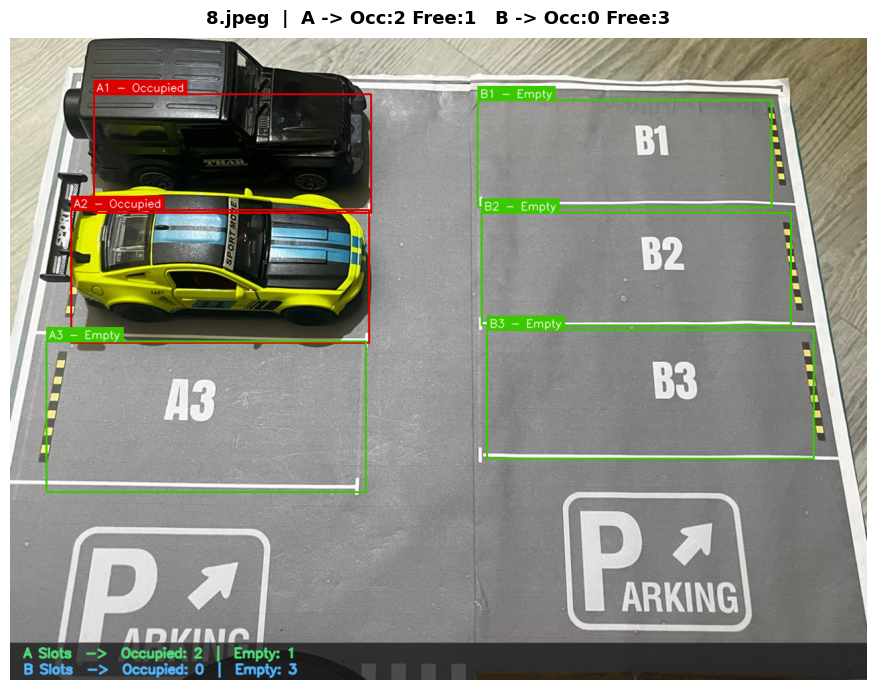

Slot   Status       Method
-----------------------------------
A1     [OCC] Occupied    via pixel_diff(101.1)
A2     [OCC] Occupied    via pixel_diff(73.5)
A3     [FREE] Empty       via clear
B1     [FREE] Empty       via clear
B2     [FREE] Empty       via clear
B3     [FREE] Empty       via clear


  Image: 9.jpeg


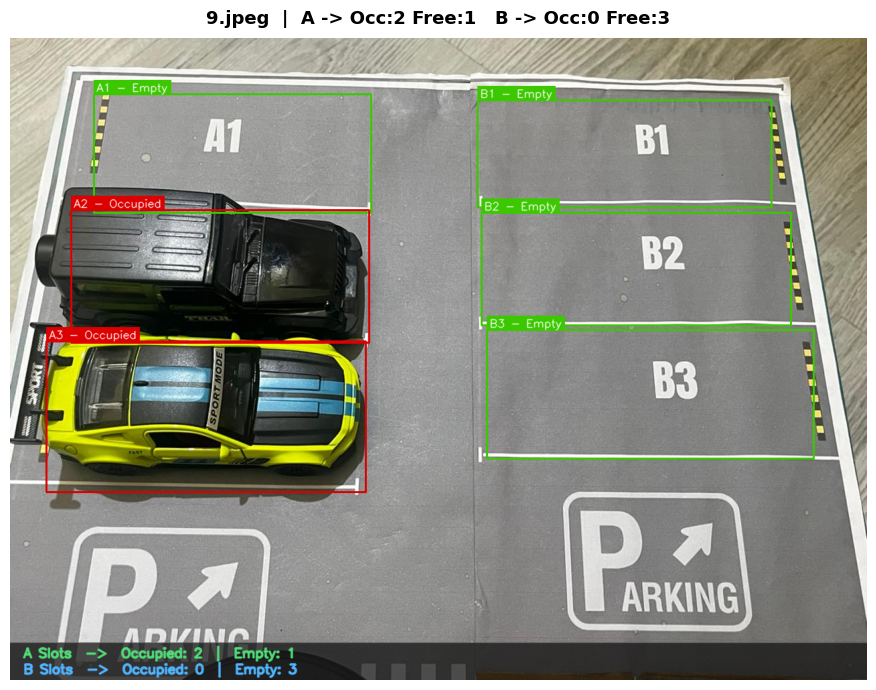

Slot   Status       Method
-----------------------------------
A1     [FREE] Empty       via clear
A2     [OCC] Occupied    via pixel_diff(86.6)
A3     [OCC] Occupied    via pixel_diff(72.3)
B1     [FREE] Empty       via clear
B2     [FREE] Empty       via clear
B3     [FREE] Empty       via clear



In [42]:
all_results = {}

for path in image_paths:
    print(f"\n{'='*55}")
    print(f"  Image: {os.path.basename(path)}")
    print('='*55)
    _, status = process_image(path, show=True)
    all_results[os.path.basename(path)] = status

## Cell 11 — Summary Table

In [ ]:
df = pd.DataFrame(all_results).T
df.index.name = 'Image'

def color_status(val):
    if val == 'Occupied':
        return 'background-color: #cc2222; color: white; font-weight: bold'
    return 'background-color: #228822; color: white; font-weight: bold'

display(df.style.map(color_status).set_caption('Parking Slot Status — All Test Images'))

## Cell 12 — Tune Thresholds (if needed)

If you get **false positives** (empty slots showing Occupied):  
→ Raise `PIXEL_DIFF_THRESH` (e.g. 40)

If you get **false negatives** (occupied slots showing Empty):  
→ Lower `CONF_THRESH` (e.g. 0.15) or lower `PIXEL_DIFF_THRESH` (e.g. 20)

In [ ]:
# Test a single image after tuning
CONF_THRESH       = 0.25   # <- tweak this
PIXEL_DIFF_THRESH = 30     # <- tweak this

TEST_IMAGE = 'parking/6.jpeg'  # <- change to whichever image had the issue
_, status = process_image(TEST_IMAGE, show=True)